In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# first we need to load the data
data = pd.read_csv('data_.csv')
print(data.head)
print("The shape of the data: ", data.shape)

<bound method NDFrame.head of                    regio1  serviceCharge  picturecount  pricetrend  \
0     Nordrhein_Westfalen         245.00             6        4.62   
1         Rheinland_Pfalz         134.00             8        3.47   
2                 Sachsen         255.00             8        2.72   
3                 Sachsen          58.15             9        1.53   
4                  Bremen         138.00            19        2.46   
...                   ...            ...           ...         ...   
1997       Sachsen_Anhalt          70.00             5        2.74   
1998    Baden_Württemberg         250.00            13        4.39   
1999              Sachsen            NaN            14        0.74   
2000       Sachsen_Anhalt         184.00             5        3.39   
2001       Sachsen_Anhalt         140.00             8        1.78   

      telekomUploadSpeed  totalRent  yearConstructed    scoutId  \
0                   10.0     840.00           1965.0   9610705

In [ ]:

print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2002 entries, 0 to 2001
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   regio1                2002 non-null   object 
 1   serviceCharge         1948 non-null   float64
 2   picturecount          2002 non-null   int64  
 3   pricetrend            1993 non-null   float64
 4   telekomUploadSpeed    1767 non-null   float64
 5   totalRent             1706 non-null   float64
 6   yearConstructed       1563 non-null   float64
 7   scoutId               2002 non-null   int64  
 8   firingTypes           1562 non-null   object 
 9   hasKitchen            2002 non-null   bool   
 10  geo_bln               2002 non-null   object 
 11  cellar                2002 non-null   bool   
 12  yearConstructedRange  1563 non-null   float64
 13  baseRent              2002 non-null   float64
 14  houseNumber           1500 non-null   object 
 15  livingS

In [3]:
print("\nDataset Description:")
print(data.describe(include='all'))


Dataset Description:
         regio1  serviceCharge  picturecount   pricetrend  telekomUploadSpeed  \
count      2002    1948.000000   2002.000000  1993.000000         1767.000000   
unique       16            NaN           NaN          NaN                 NaN   
top     Sachsen            NaN           NaN          NaN                 NaN   
freq        518            NaN           NaN          NaN                 NaN   
mean        NaN     148.367500      9.846154     3.248495           28.898132   
std         NaN      89.349652      6.132903     2.077292           16.549395   
min         NaN       0.000000      0.000000    -8.260000            1.000000   
25%         NaN      94.000000      6.000000     1.820000           10.000000   
50%         NaN     131.000000      9.000000     3.280000           40.000000   
75%         NaN     185.000000     13.000000     4.470000           40.000000   
max         NaN    1200.000000     53.000000    11.540000          100.000000   

     

In [ ]:

# 2. Handle Missing Values
#  col with more than 70 percent missing value are removed
threshold = len(data) * 0.7
data = data.dropna(axis=1, thresh=threshold)
print(data.head())
print(data.shape)
# 2 cols have been removed due to more than 70% missing values

                regio1  serviceCharge  picturecount  pricetrend  \
0  Nordrhein_Westfalen         245.00             6        4.62   
1      Rheinland_Pfalz         134.00             8        3.47   
2              Sachsen         255.00             8        2.72   
3              Sachsen          58.15             9        1.53   
4               Bremen         138.00            19        2.46   

   telekomUploadSpeed  totalRent  yearConstructed    scoutId  \
0                10.0      840.0           1965.0   96107057   
1                10.0        NaN           1871.0  111378734   
2                 2.4     1300.0           2019.0  113147523   
3                40.0        NaN           1964.0  108890903   
4                 NaN      903.0           1950.0  114751222   

        firingTypes  hasKitchen  ... houseNumber  livingSpace       condition  \
0               oil       False  ...         244        86.00       well_kept   
1               gas       False  ...         NaN  

In [ ]:
# we will fill the numerical attribute missing values with the median of the col
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
print(data.info())
# all the numerical cols have been filled with the median values wherever there was a NULL

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2002 entries, 0 to 2001
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   regio1                2002 non-null   object 
 1   serviceCharge         2002 non-null   float64
 2   picturecount          2002 non-null   int64  
 3   pricetrend            2002 non-null   float64
 4   telekomUploadSpeed    2002 non-null   float64
 5   totalRent             2002 non-null   float64
 6   yearConstructed       2002 non-null   float64
 7   scoutId               2002 non-null   int64  
 8   firingTypes           1562 non-null   object 
 9   hasKitchen            2002 non-null   bool   
 10  geo_bln               2002 non-null   object 
 11  cellar                2002 non-null   bool   
 12  yearConstructedRange  2002 non-null   float64
 13  baseRent              2002 non-null   float64
 14  houseNumber           1500 non-null   object 
 15  livingSpace          

In [ ]:
# for the categorical col we will use mode
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2002 entries, 0 to 2001
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   regio1                2002 non-null   object 
 1   serviceCharge         2002 non-null   float64
 2   picturecount          2002 non-null   int64  
 3   pricetrend            2002 non-null   float64
 4   telekomUploadSpeed    2002 non-null   float64
 5   totalRent             2002 non-null   float64
 6   yearConstructed       2002 non-null   float64
 7   scoutId               2002 non-null   int64  
 8   firingTypes           2002 non-null   object 
 9   hasKitchen            2002 non-null   bool   
 10  geo_bln               2002 non-null   object 
 11  cellar                2002 non-null   bool   
 12  yearConstructedRange  2002 non-null   float64
 13  baseRent              2002 non-null   float64
 14  houseNumber           2002 non-null   object 
 15  livingSpace          

In [ ]:
# counting the number of duplicate rows
num_duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")


Number of duplicate rows: 0


In [ ]:
print(data.shape)
data = data.drop_duplicates()
print(data.shape)
# no duplicates are found


(2002, 24)
(2002, 24)


In [ ]:
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 2* IQR
    upper_bound = Q3 + 2* IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
# using a factor of 2 instead of 1.5 times the IQR to preserve the data. the factor of 2 is more suitable for this dataframe
print(data.shape)

(1337, 24)


In [ ]:
for col in cat_cols:
    data[col] = data[col].str.strip().str.lower()

data.reset_index(drop=True, inplace=True)

print("\nCleaned Dataset Info:")
print(data.info())
print("\nCleaned Dataset Preview:")
print(data.info())


Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   regio1                1337 non-null   object 
 1   serviceCharge         1337 non-null   float64
 2   picturecount          1337 non-null   int64  
 3   pricetrend            1337 non-null   float64
 4   telekomUploadSpeed    1337 non-null   float64
 5   totalRent             1337 non-null   float64
 6   yearConstructed       1337 non-null   float64
 7   scoutId               1337 non-null   int64  
 8   firingTypes           1337 non-null   object 
 9   hasKitchen            1337 non-null   bool   
 10  geo_bln               1337 non-null   object 
 11  cellar                1337 non-null   bool   
 12  yearConstructedRange  1337 non-null   float64
 13  baseRent              1337 non-null   float64
 14  houseNumber           1337 non-null   object 
 15

In [ ]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Basic summary statistics
print("Summary Statistics:")
print(data[num_cols].describe())

# Additional statistics: mode, variance, skewness
print("\nMode:")
print(data[num_cols].mode().iloc[0])  

print("\nVariance:")
print(data[num_cols].var())

print("\nSkewness:")
print(data[num_cols].skew())



Summary Statistics:
       serviceCharge  picturecount   pricetrend  telekomUploadSpeed  \
count    1337.000000   1337.000000  1337.000000         1337.000000   
mean      128.917831      8.818250     2.937277           30.211518   
std        56.348524      4.914907     1.916465           15.773104   
min         0.000000      0.000000    -2.220000            1.000000   
25%        90.000000      6.000000     1.670000           10.000000   
50%       125.000000      8.000000     3.080000           40.000000   
75%       160.000000     12.000000     4.110000           40.000000   
max       330.000000     27.000000     9.470000           40.000000   

         totalRent  yearConstructed       scoutId  yearConstructedRange  \
count  1337.000000      1337.000000  1.337000e+03           1337.000000   
mean    616.174402      1963.728497  1.105521e+08              2.833209   
std     238.932372        27.898936  4.455036e+06              1.473774   
min       0.000000      1899.000000  9.3

In [12]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   regio1                1337 non-null   object 
 1   serviceCharge         1337 non-null   float64
 2   picturecount          1337 non-null   int64  
 3   pricetrend            1337 non-null   float64
 4   telekomUploadSpeed    1337 non-null   float64
 5   totalRent             1337 non-null   float64
 6   yearConstructed       1337 non-null   float64
 7   scoutId               1337 non-null   int64  
 8   firingTypes           1337 non-null   object 
 9   hasKitchen            1337 non-null   bool   
 10  geo_bln               1337 non-null   object 
 11  cellar                1337 non-null   bool   
 12  yearConstructedRange  1337 non-null   float64
 13  baseRent              1337 non-null   float64
 14  houseNumber           1337 non-null   object 
 15  livingSpace          

In [ ]:
cat_cols = data.select_dtypes(include=['object', 'bool']).columns

for col in cat_cols:
    print(f"\nFrequency Distribution for '{col}':")
    print(data[col].value_counts())


Frequency Distribution for 'regio1':
regio1
sachsen                   379
nordrhein_westfalen       321
sachsen_anhalt            131
hessen                     65
bayern                     62
baden_württemberg          62
niedersachsen              59
thüringen                  53
brandenburg                44
rheinland_pfalz            40
mecklenburg_vorpommern     36
berlin                     32
schleswig_holstein         30
bremen                      8
hamburg                     8
saarland                    7
Name: count, dtype: int64

Frequency Distribution for 'firingTypes':
firingTypes
gas                                            832
district_heating                               259
oil                                             93
natural_gas_light                               57
natural_gas_heavy                               23
electricity                                     20
steam_district_heating                          10
gas:electricity                      

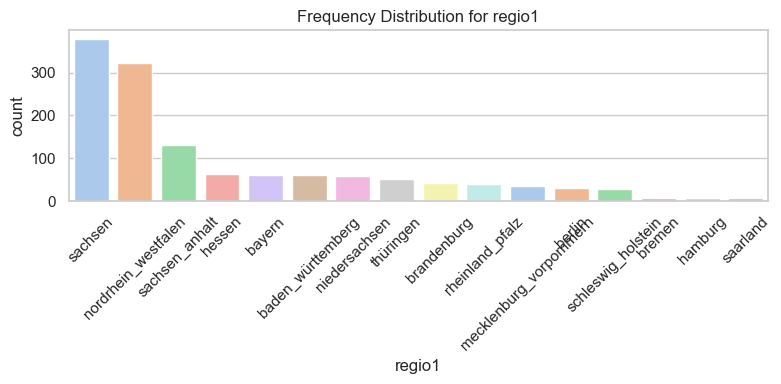

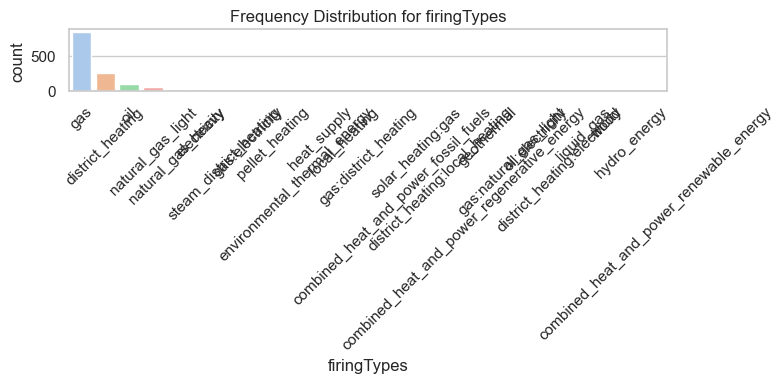

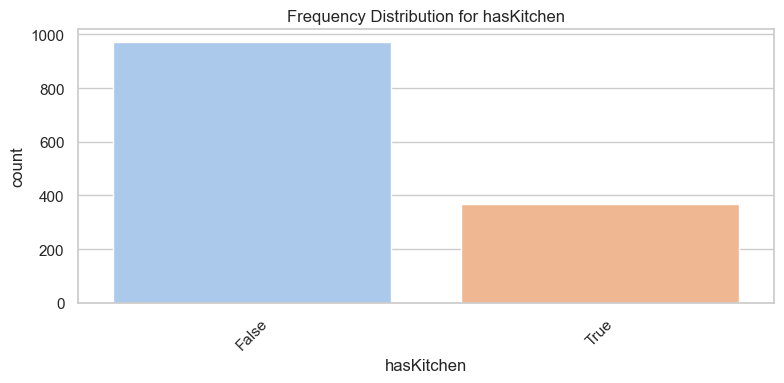

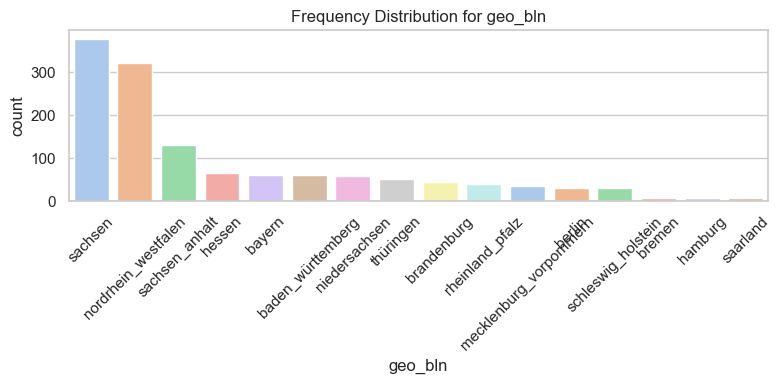

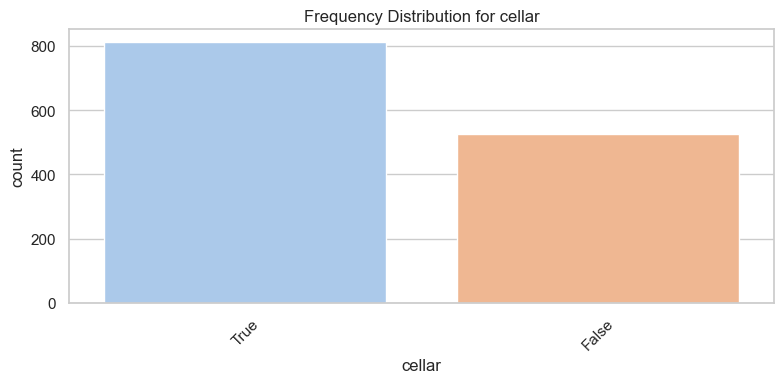

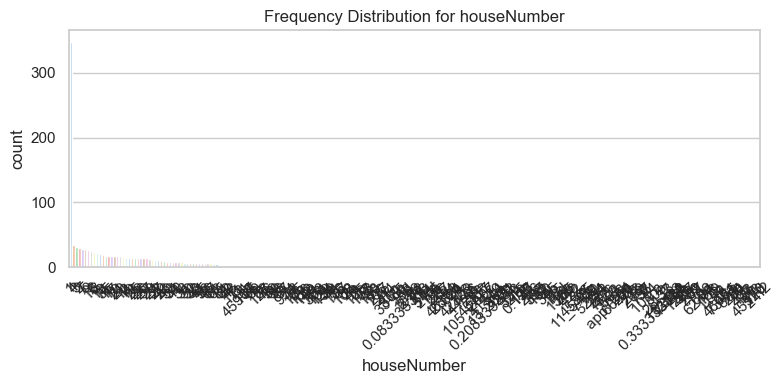

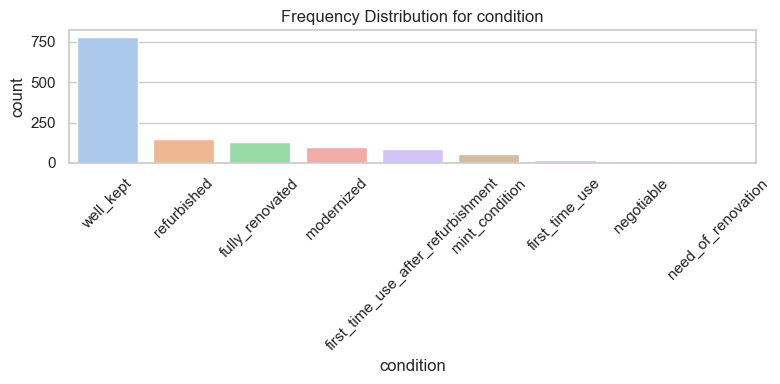

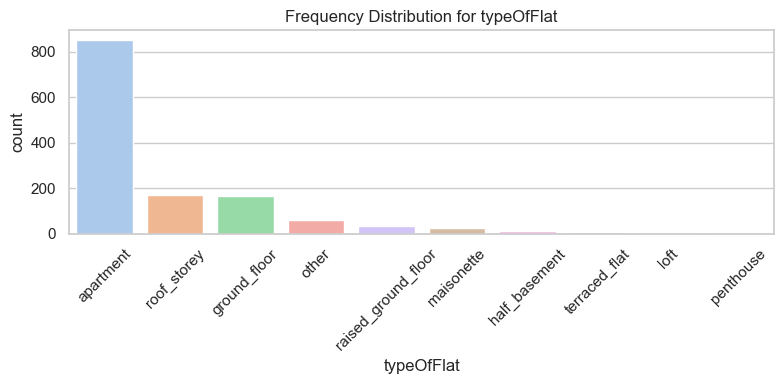

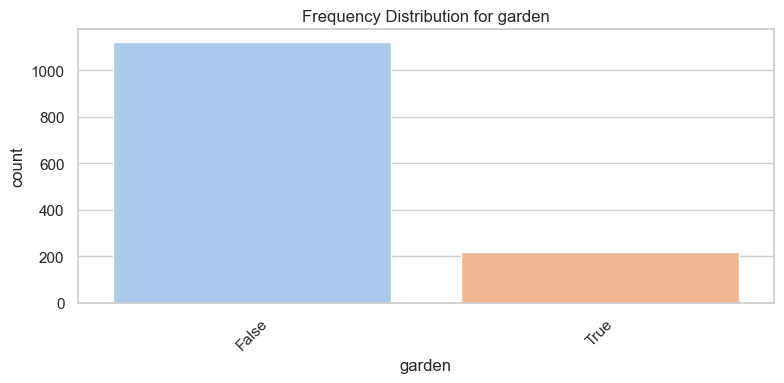

In [ ]:
sns.set(style="whitegrid")

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index, palette='pastel')
    plt.title(f'Frequency Distribution for {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


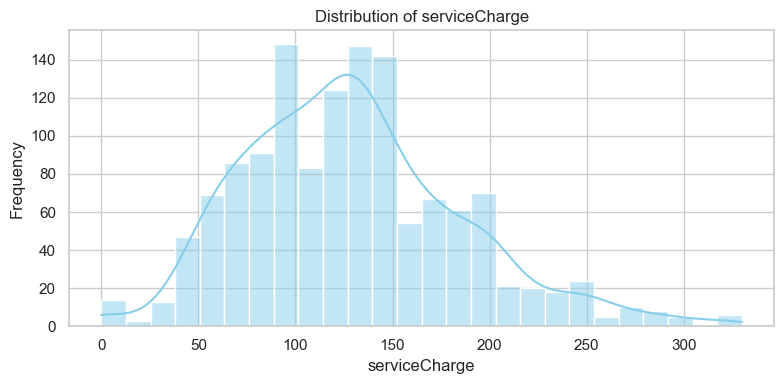

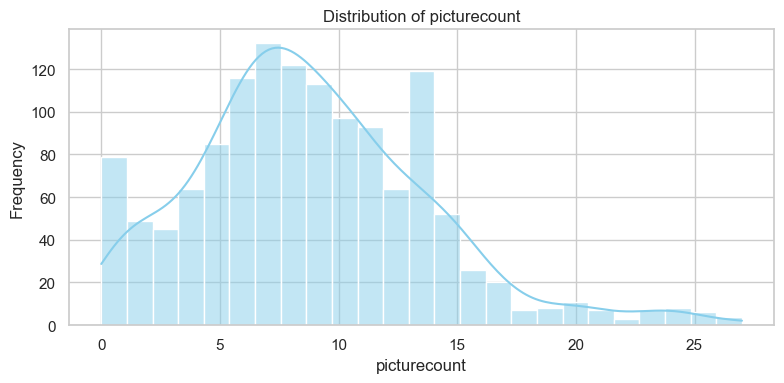

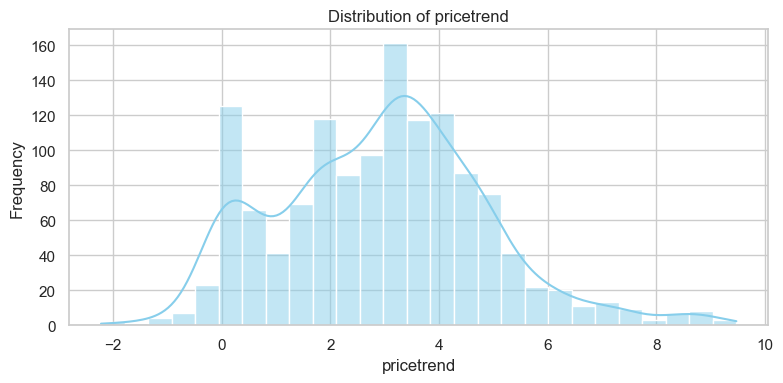

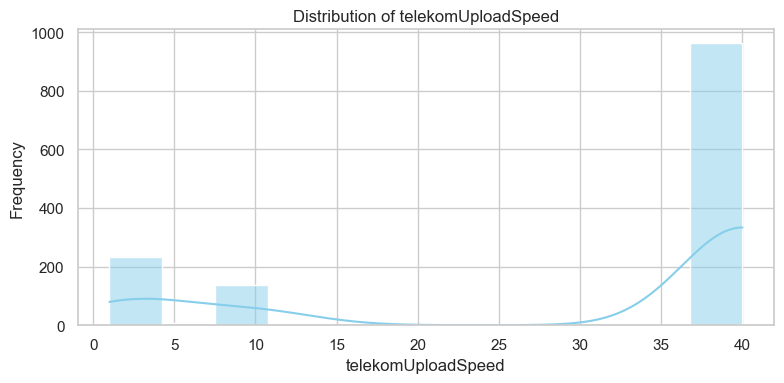

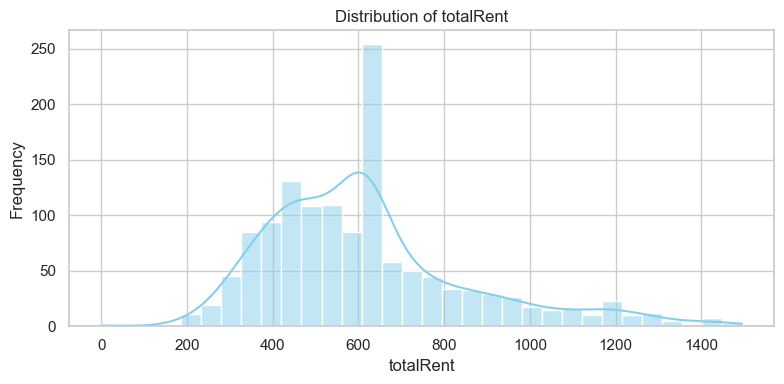

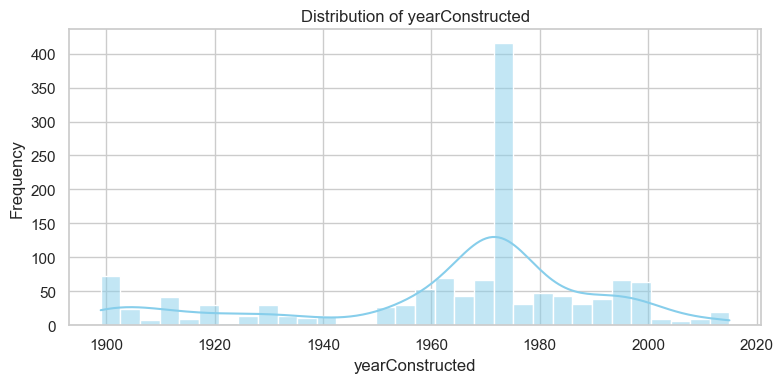

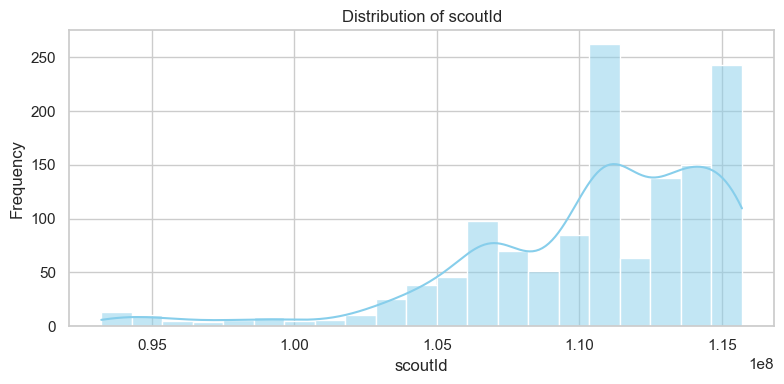

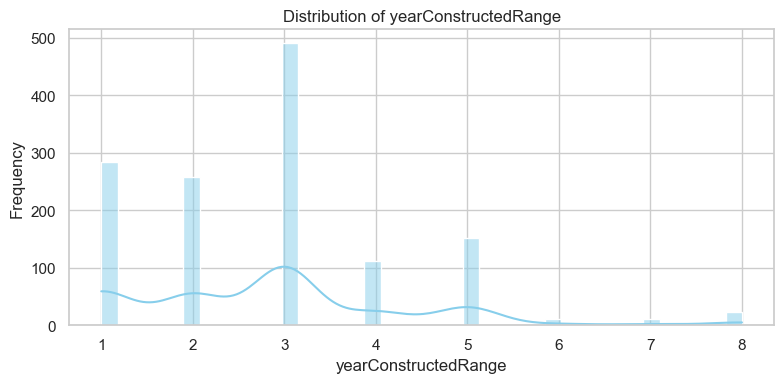

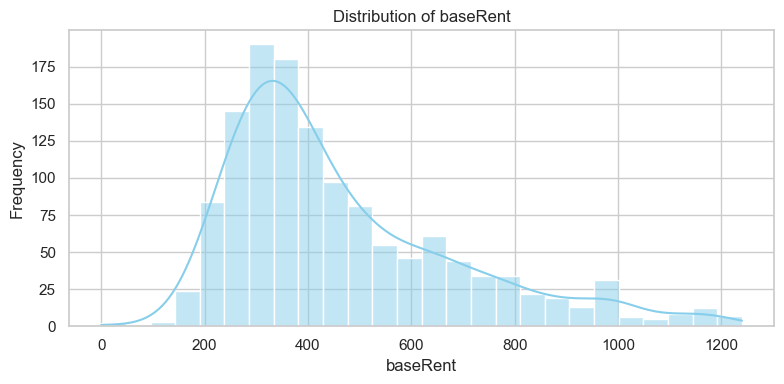

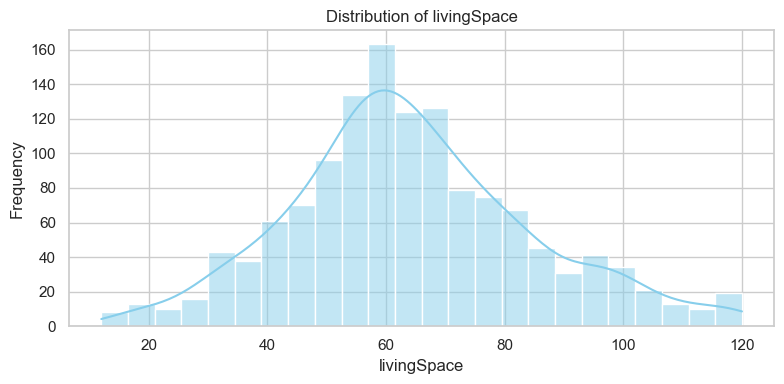

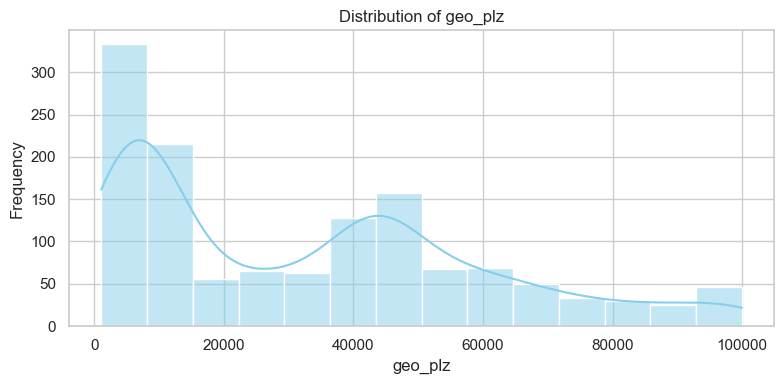

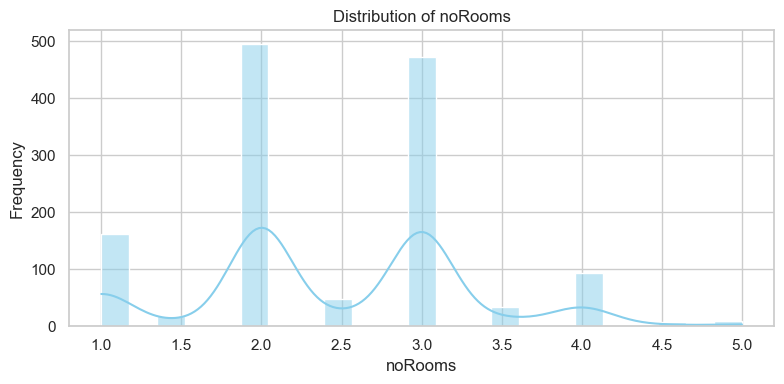

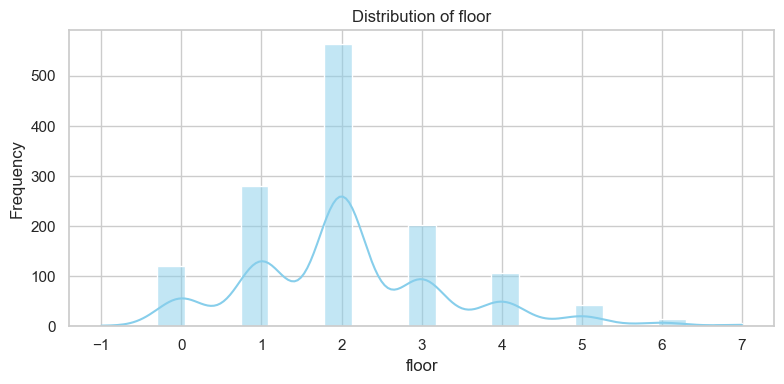

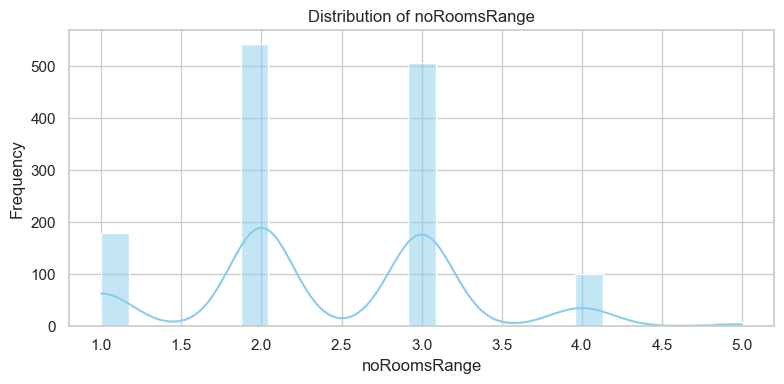

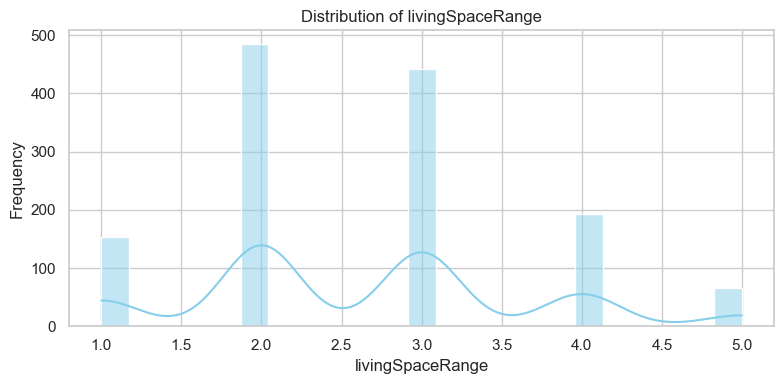

In [ ]:
# Histograms 
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


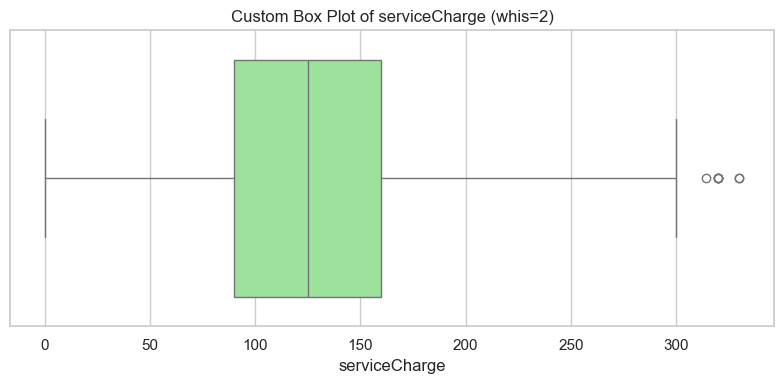

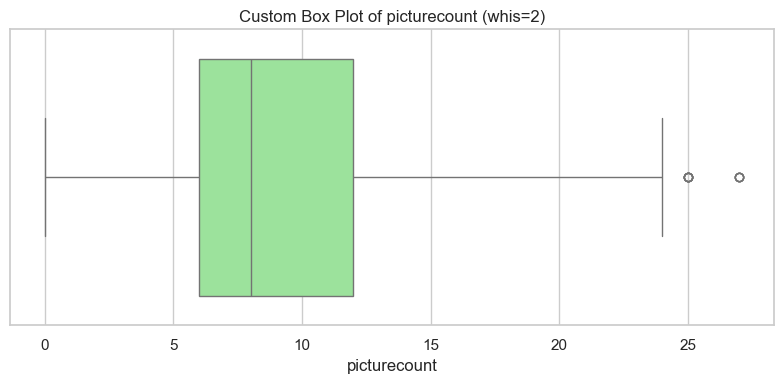

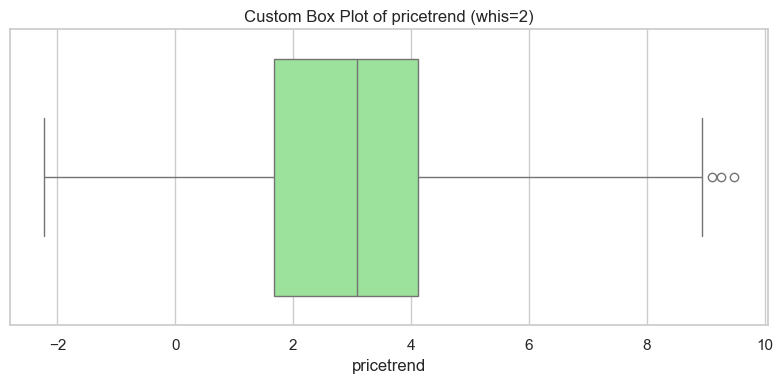

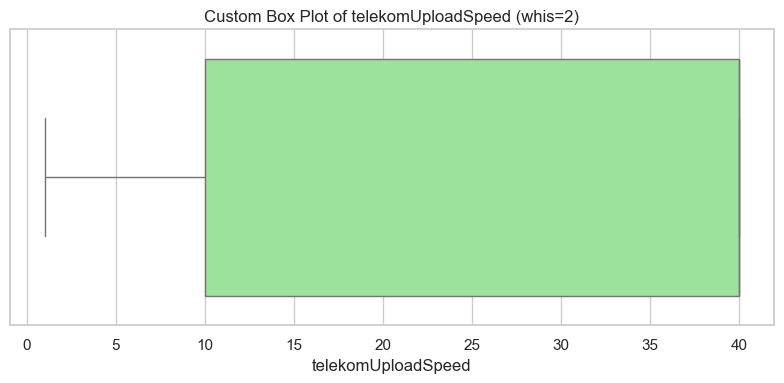

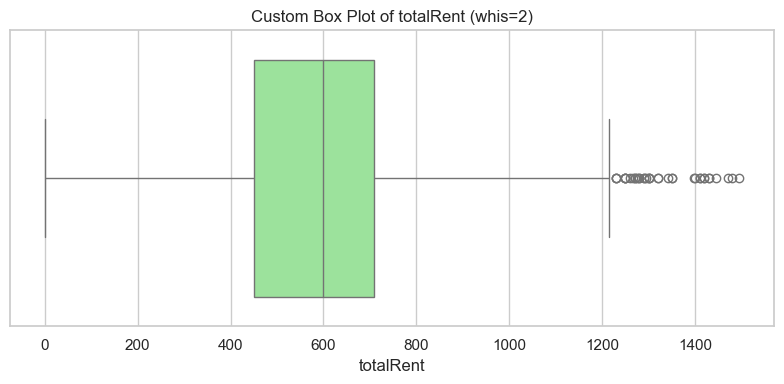

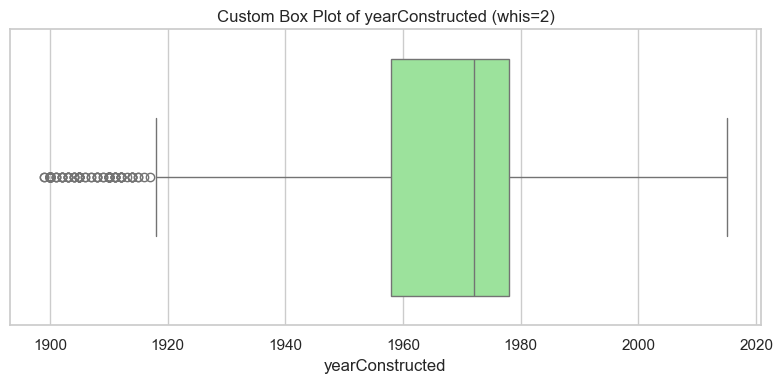

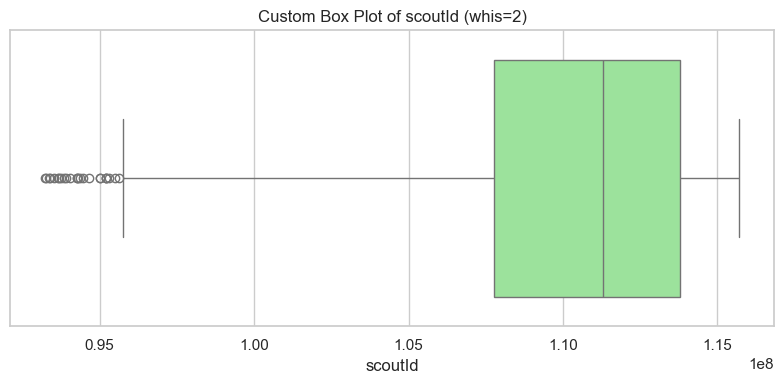

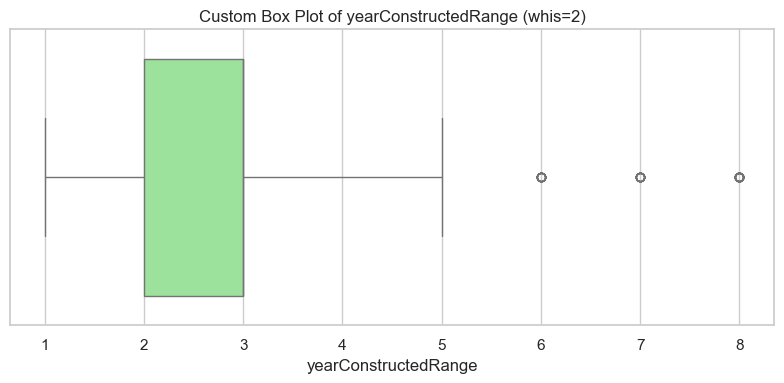

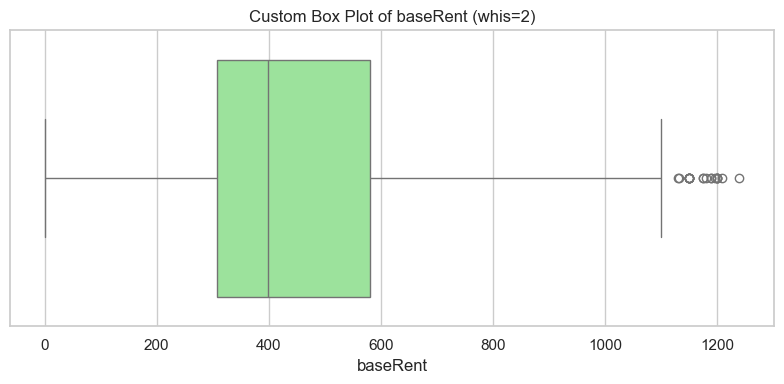

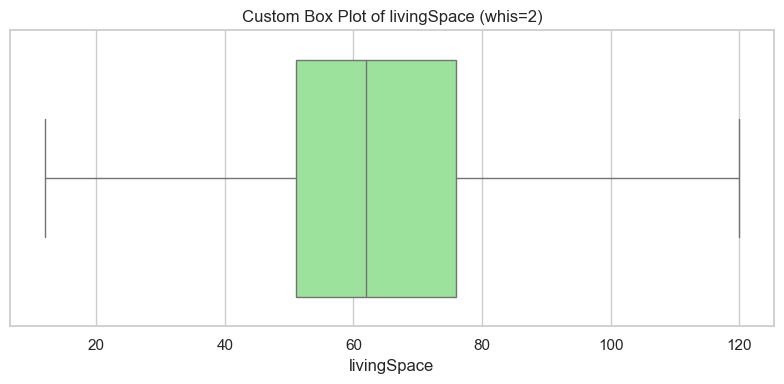

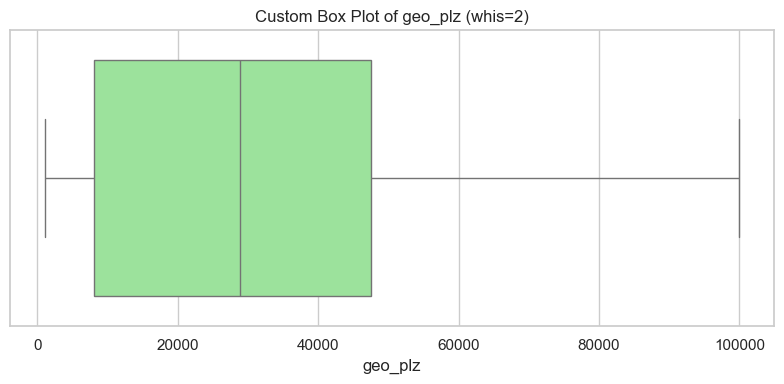

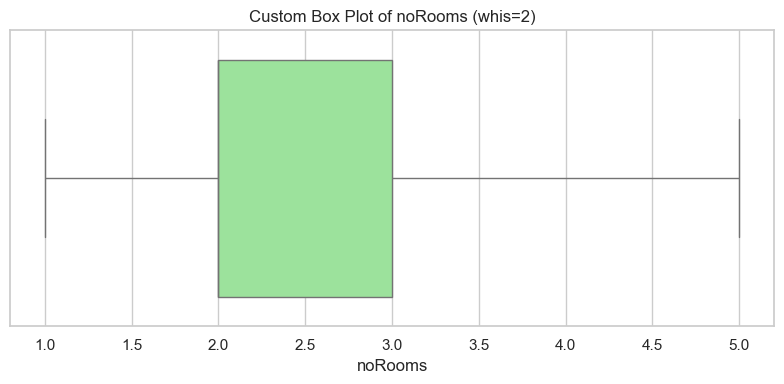

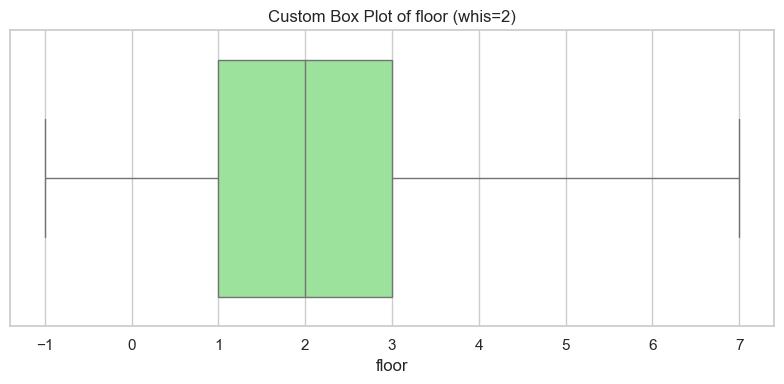

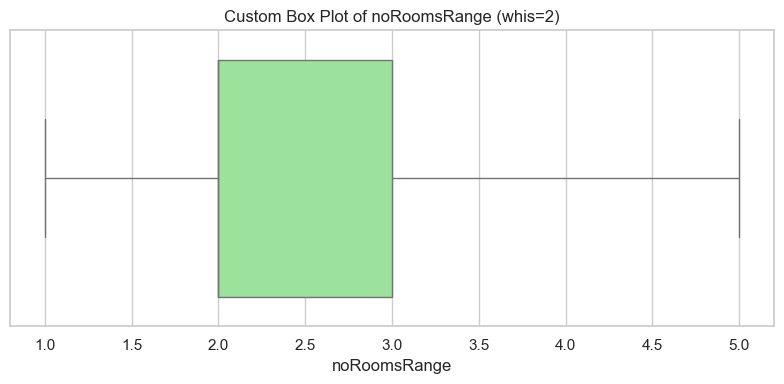

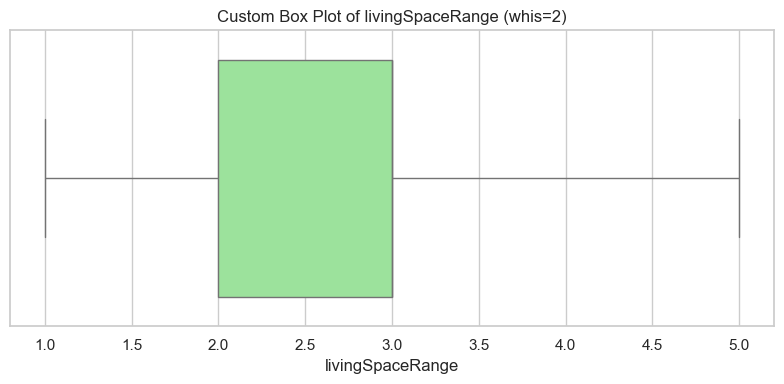

In [ ]:
# Boxplot
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col], color='lightgreen', whis=2)
    plt.title(f'Custom Box Plot of {col} (whis=2)')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()



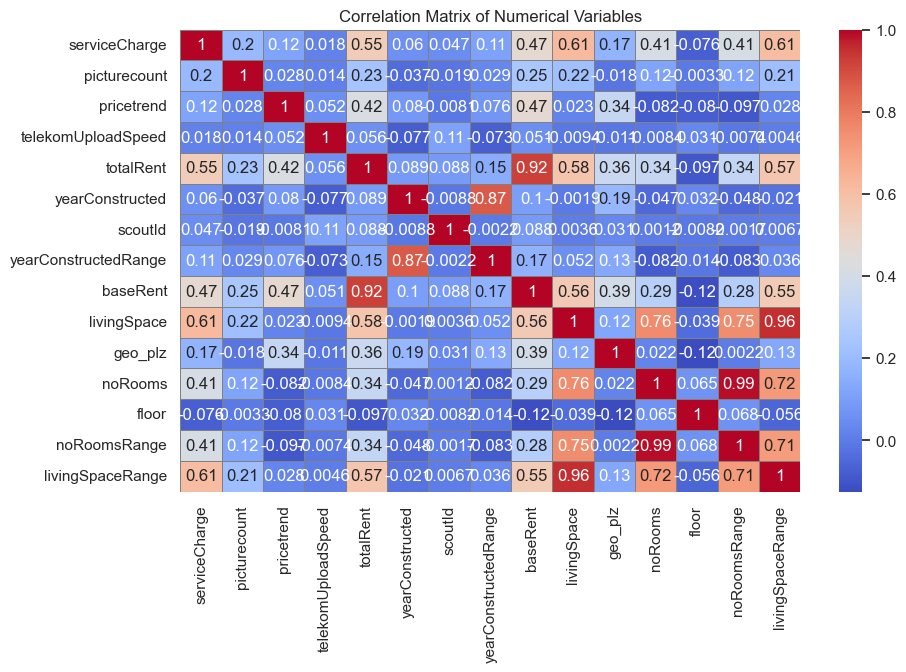

In [ ]:
# Correlation matrix
corr = data[num_cols].corr()

# Heat maps
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='gray')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


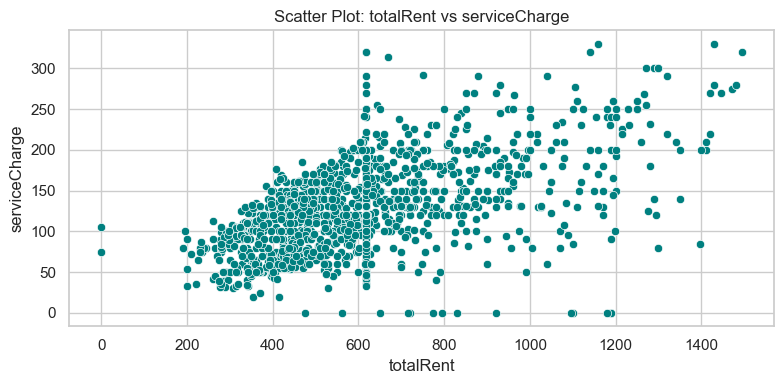

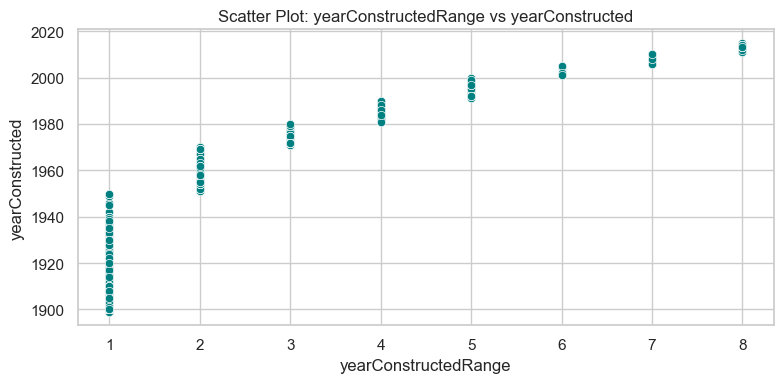

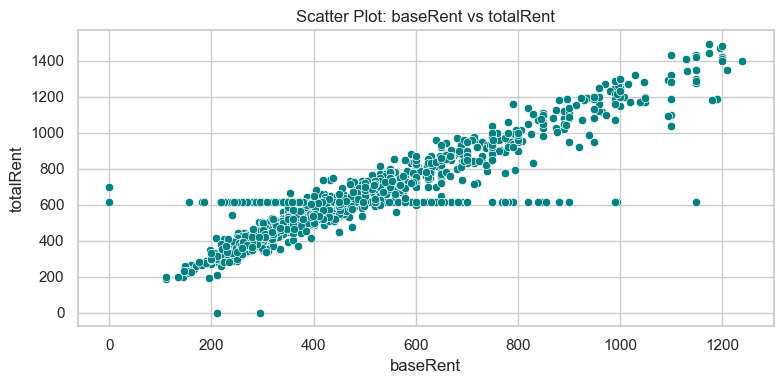

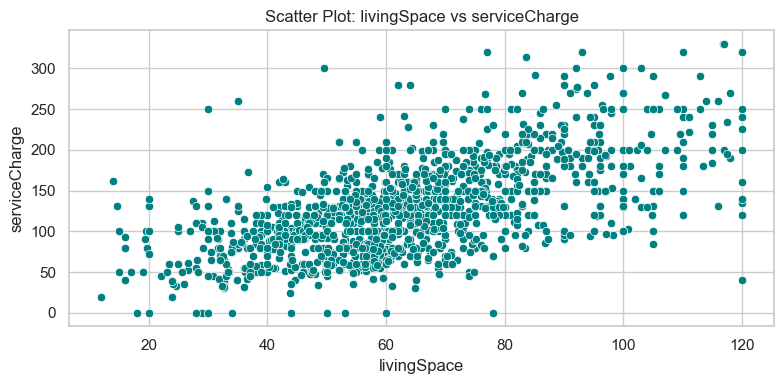

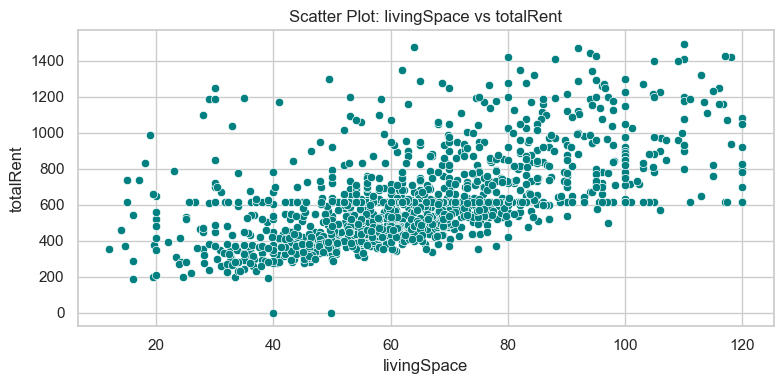

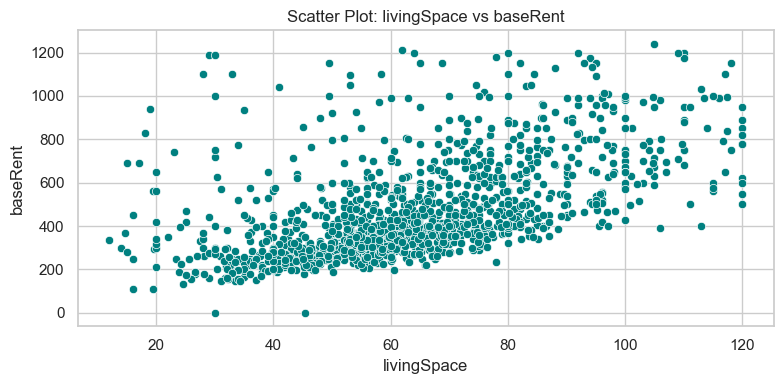

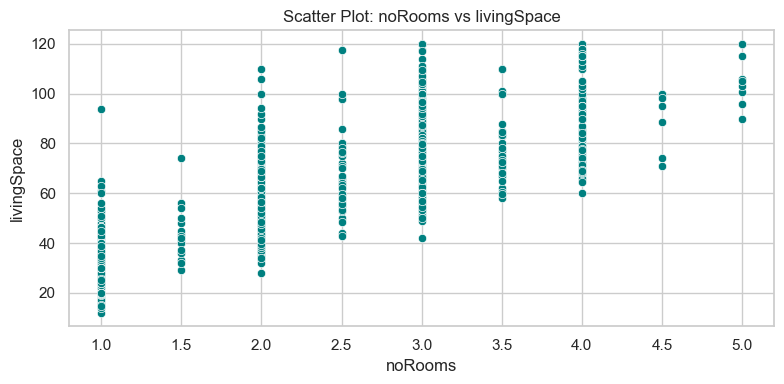

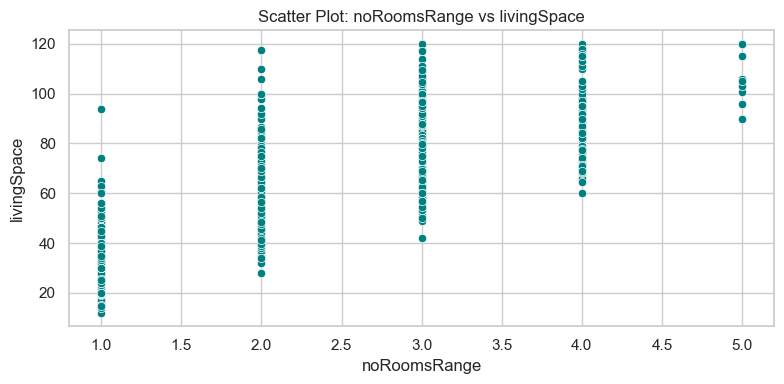

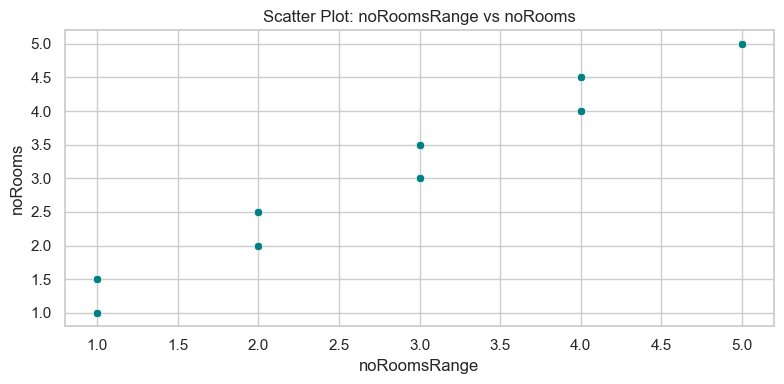

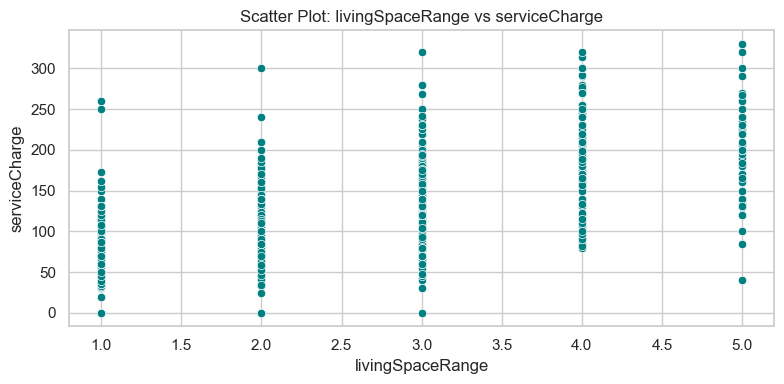

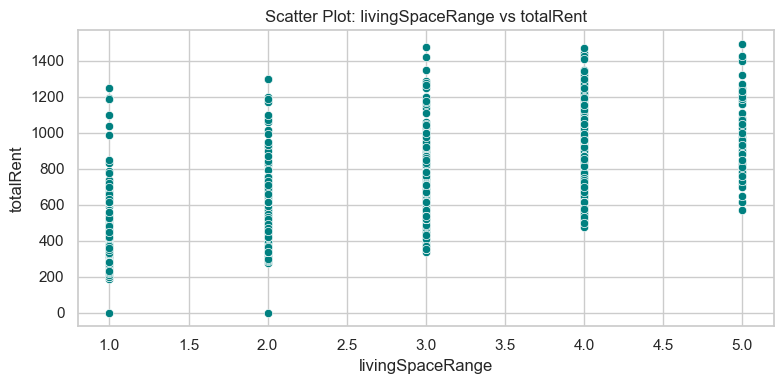

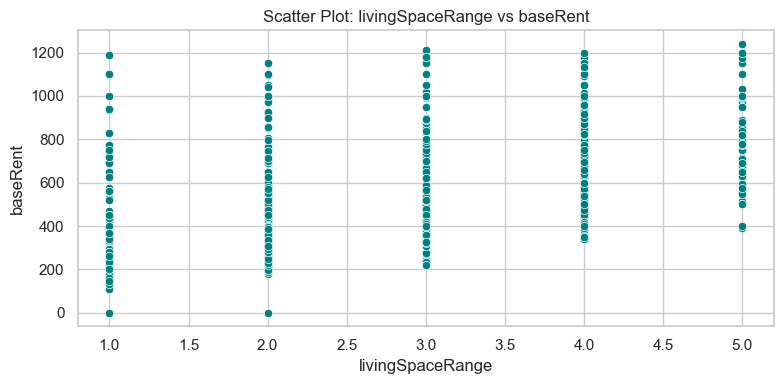

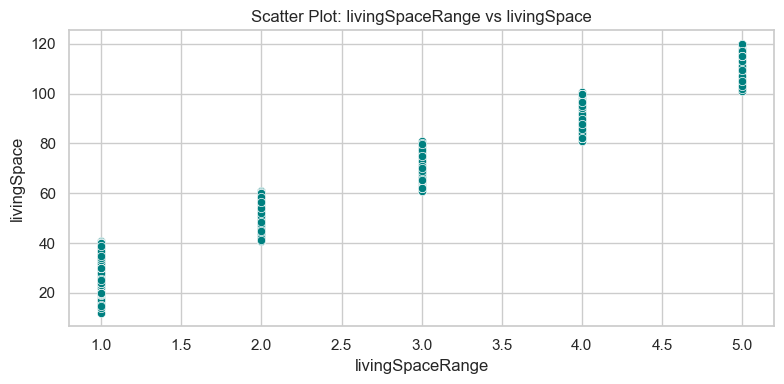

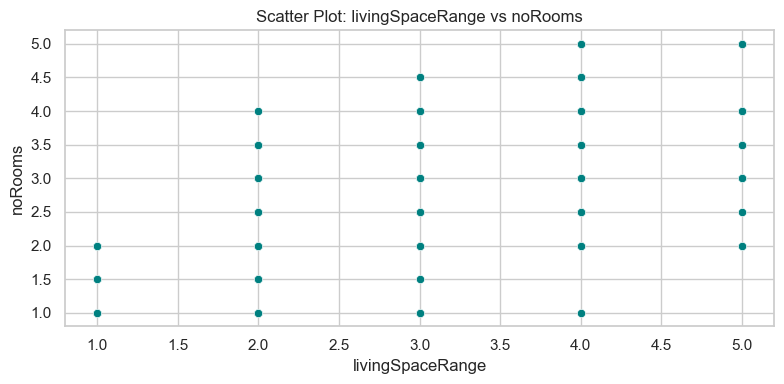

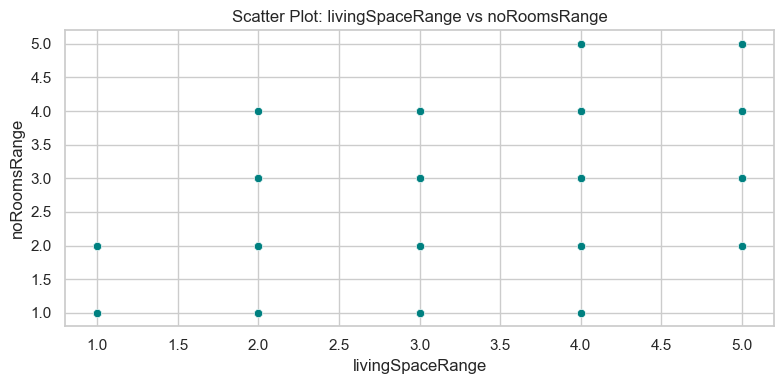

In [ ]:
def get_top_correlations(df, threshold=0.5):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    return [(col, row) for col in upper.columns for row in upper.index if upper.loc[row, col] > threshold]

top_pairs = get_top_correlations(data[num_cols])

for x, y in top_pairs:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=data, x=x, y=y, color='teal')
    plt.title(f'Scatter Plot: {x} vs {y}')
    plt.tight_layout()
    plt.show()


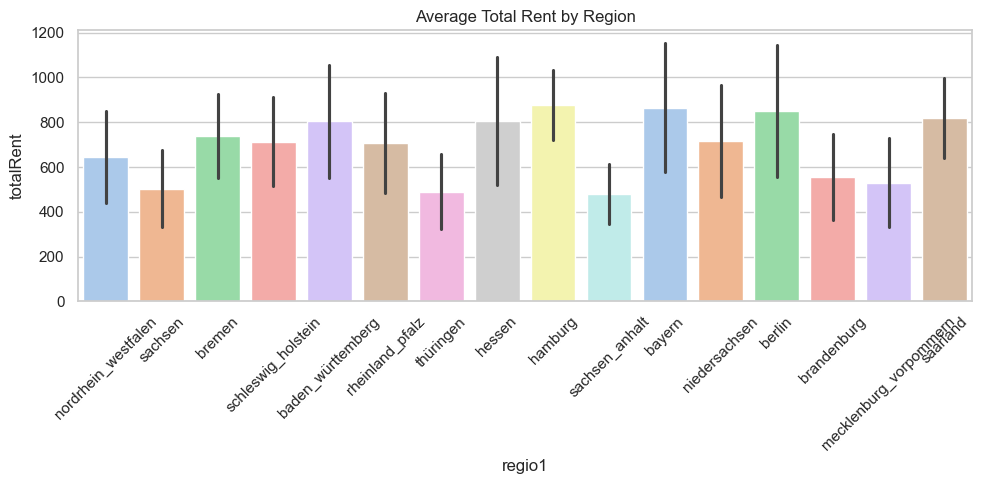

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x='regio1', y='totalRent', palette='pastel', ci='sd')
plt.title('Average Total Rent by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


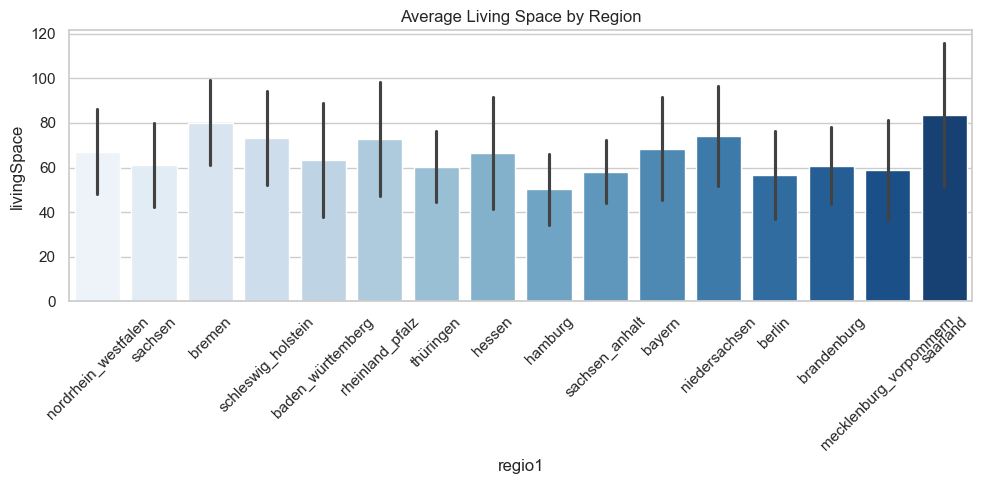

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x='regio1', y='livingSpace', palette='Blues', ci='sd')
plt.title('Average Living Space by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


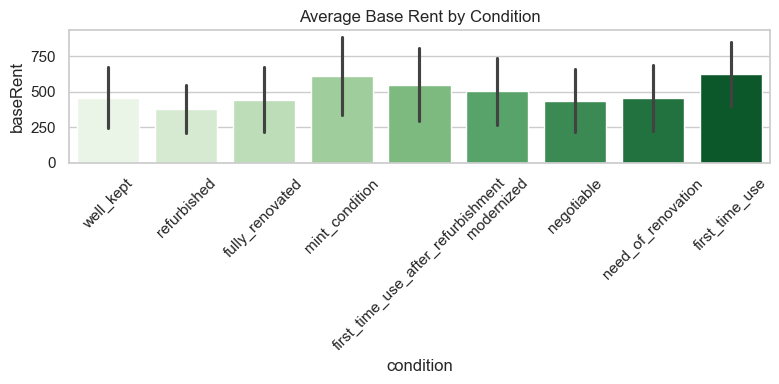

In [21]:
plt.figure(figsize=(8, 4))
sns.barplot(data=data, x='condition', y='baseRent', palette='Greens', ci='sd')
plt.title('Average Base Rent by Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


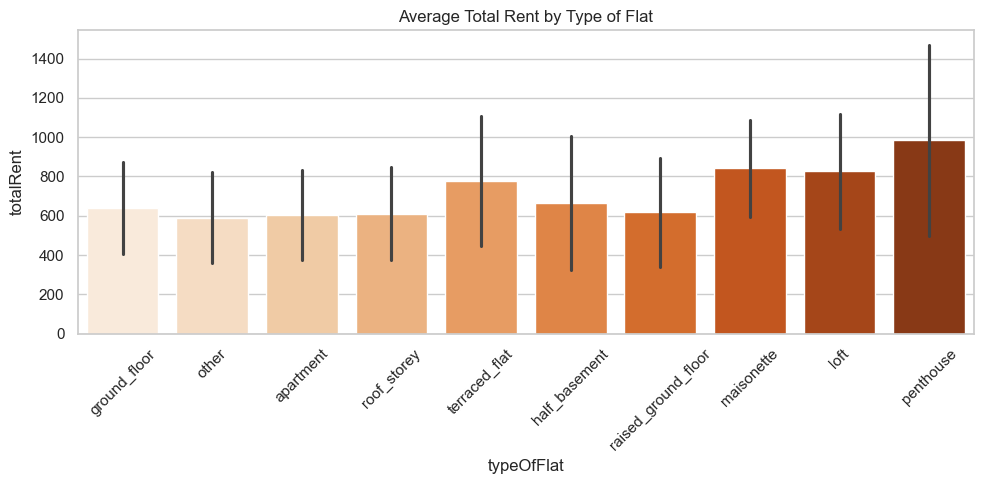

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x='typeOfFlat', y='totalRent', palette='Oranges', ci='sd')
plt.title('Average Total Rent by Type of Flat')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


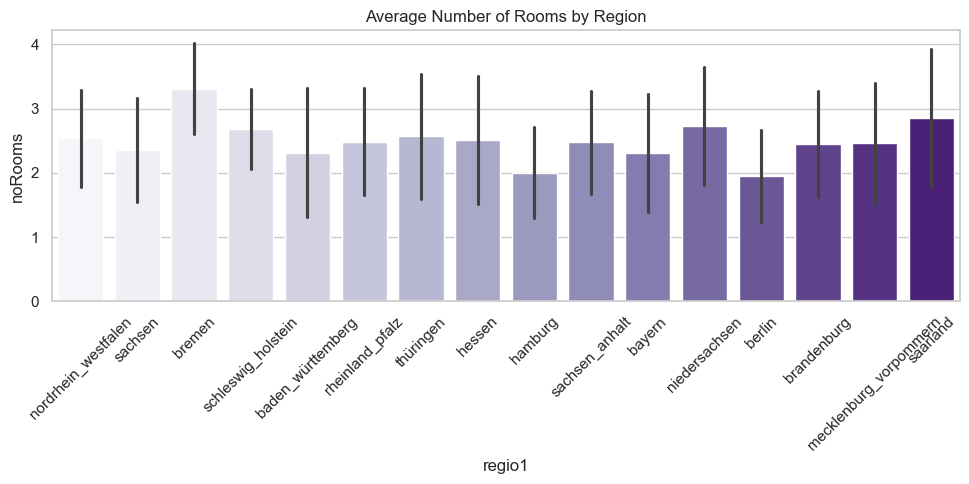

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x='regio1', y='noRooms', palette='Purples', ci='sd')
plt.title('Average Number of Rooms by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


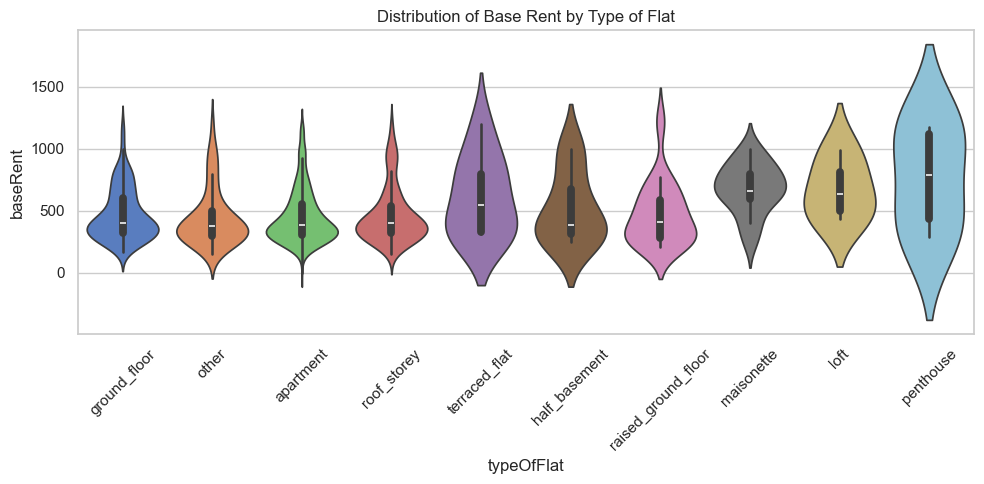

In [24]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=data, x='typeOfFlat', y='baseRent', palette='muted')
plt.title('Distribution of Base Rent by Type of Flat')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


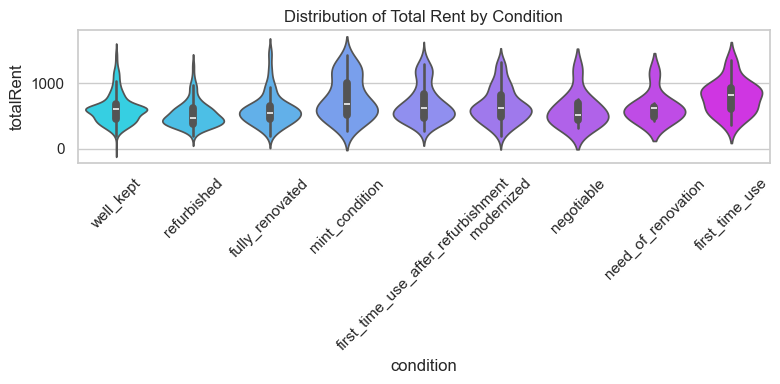

In [25]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=data, x='condition', y='totalRent', palette='cool')
plt.title('Distribution of Total Rent by Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


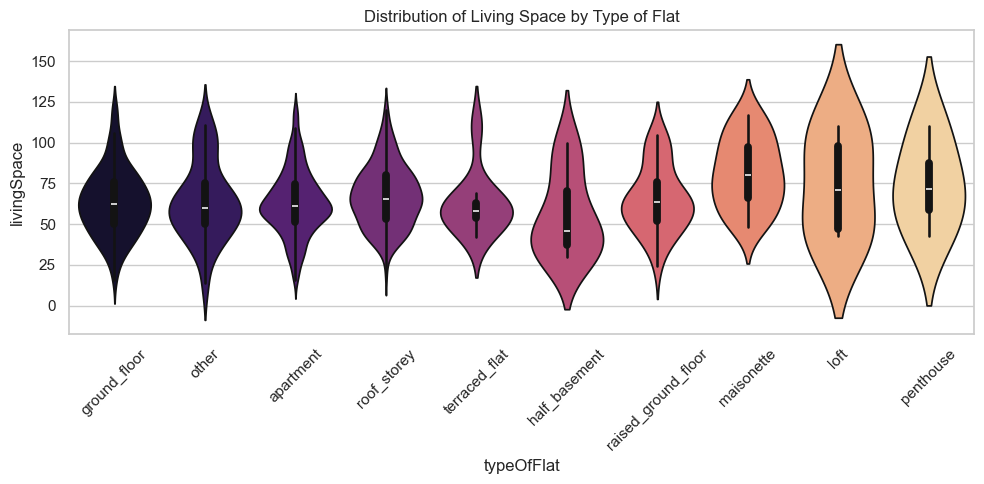

In [26]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=data, x='typeOfFlat', y='livingSpace', palette='magma')
plt.title('Distribution of Living Space by Type of Flat')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


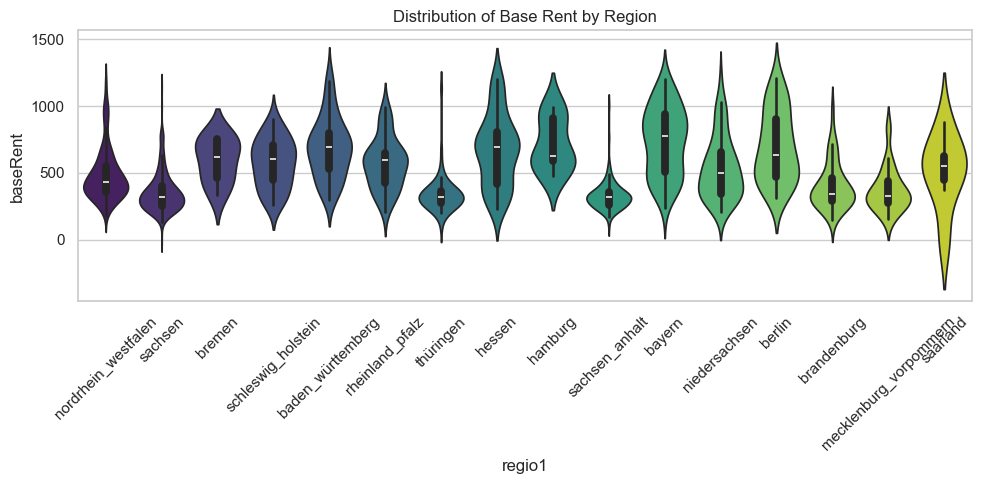

In [27]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=data, x='regio1', y='baseRent', palette='viridis')
plt.title('Distribution of Base Rent by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


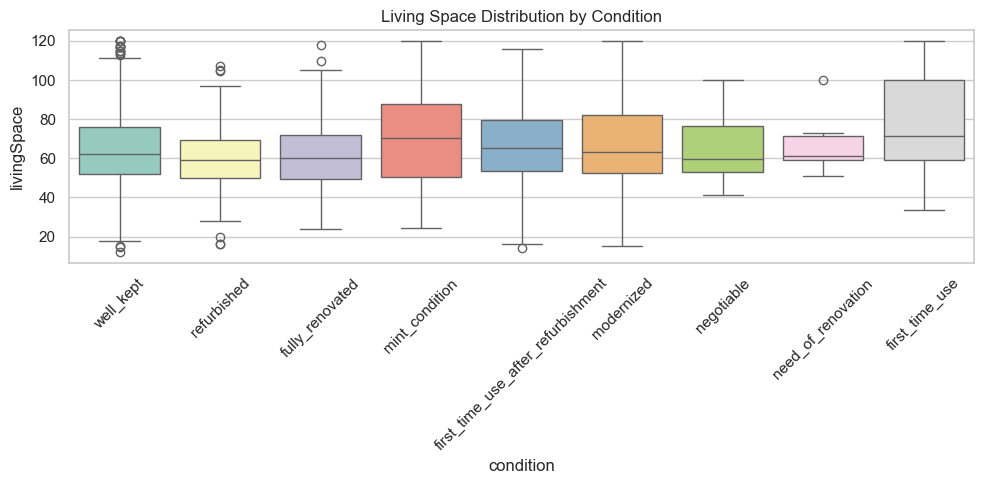

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='condition', y='livingSpace', palette='Set3')
plt.title('Living Space Distribution by Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


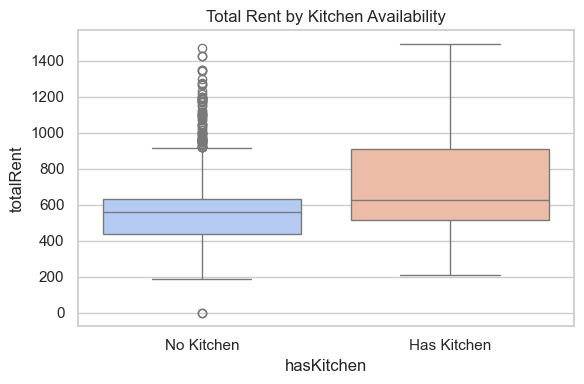

In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x='hasKitchen', y='totalRent', palette='coolwarm')
plt.title('Total Rent by Kitchen Availability')
plt.xticks([0, 1], ['No Kitchen', 'Has Kitchen'])
plt.tight_layout()
plt.show()


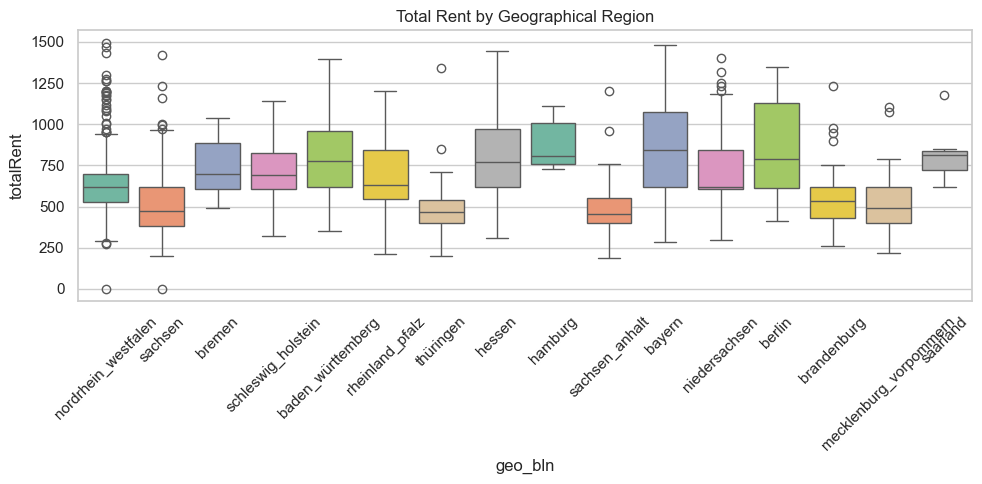

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='geo_bln', y='totalRent', palette='Set2')
plt.title('Total Rent by Geographical Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


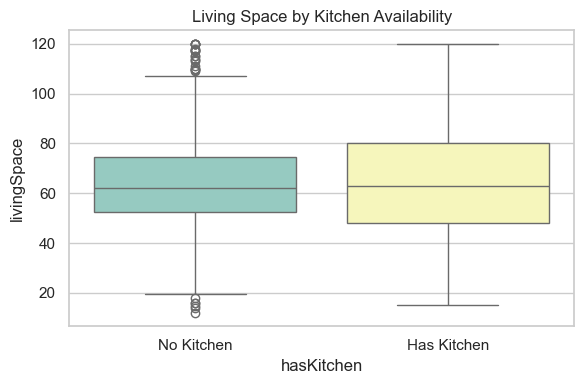

In [31]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x='hasKitchen', y='livingSpace', palette='Set3')
plt.title('Living Space by Kitchen Availability')
plt.xticks([0, 1], ['No Kitchen', 'Has Kitchen'])
plt.tight_layout()
plt.show()


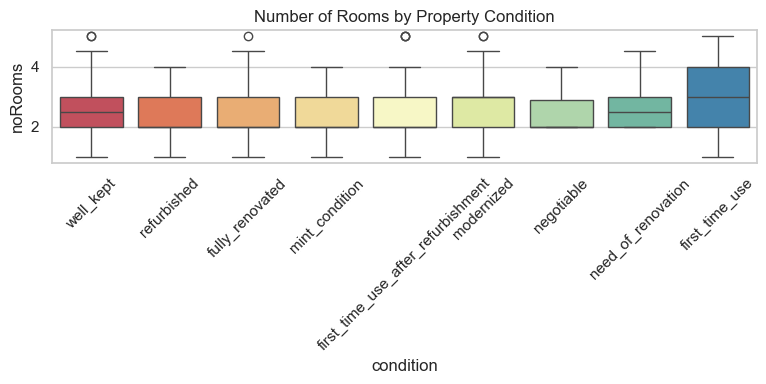

In [32]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=data, x='condition', y='noRooms', palette='Spectral')
plt.title('Number of Rooms by Property Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


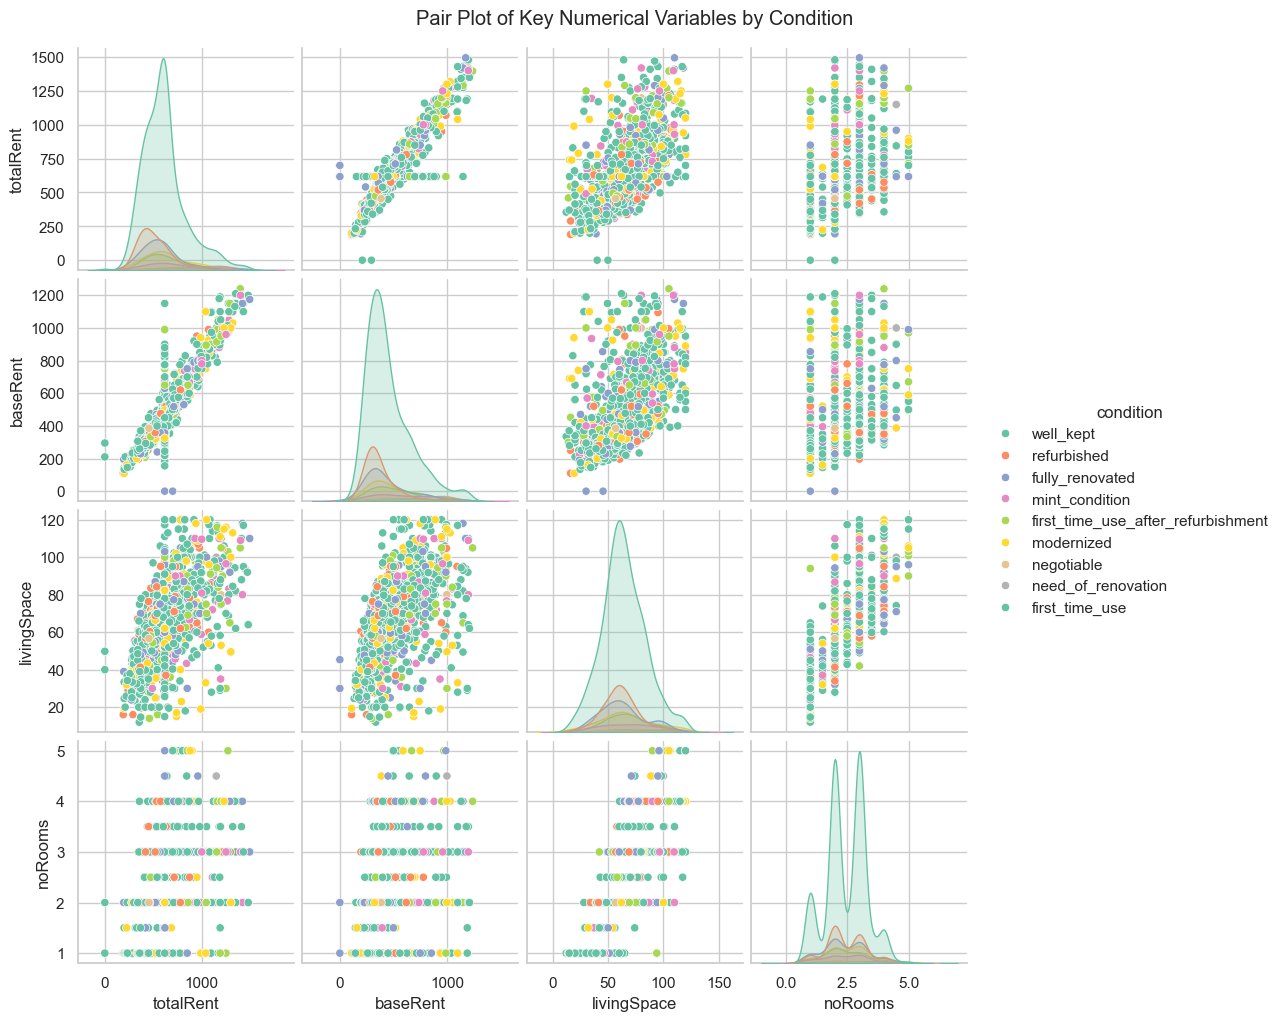

In [33]:
sns.pairplot(data, vars=['totalRent', 'baseRent', 'livingSpace', 'noRooms'], hue='condition', palette='Set2', diag_kind='kde')
plt.suptitle('Pair Plot of Key Numerical Variables by Condition', y=1.02)
plt.show()


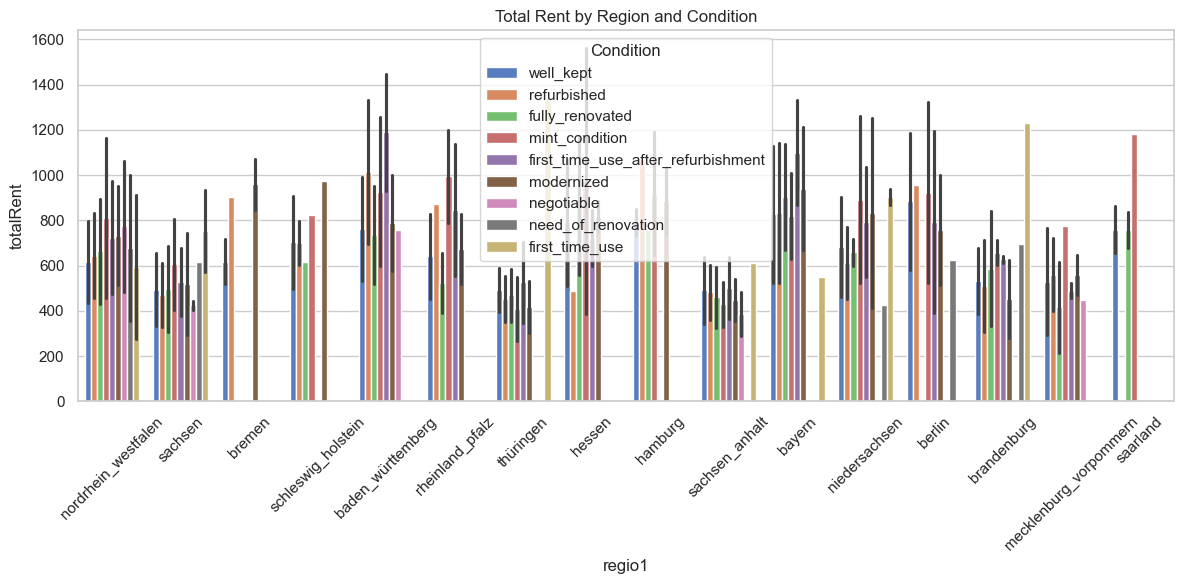

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data, x='regio1', y='totalRent', hue='condition', palette='muted', ci='sd')
plt.title('Total Rent by Region and Condition')
plt.xticks(rotation=45)
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


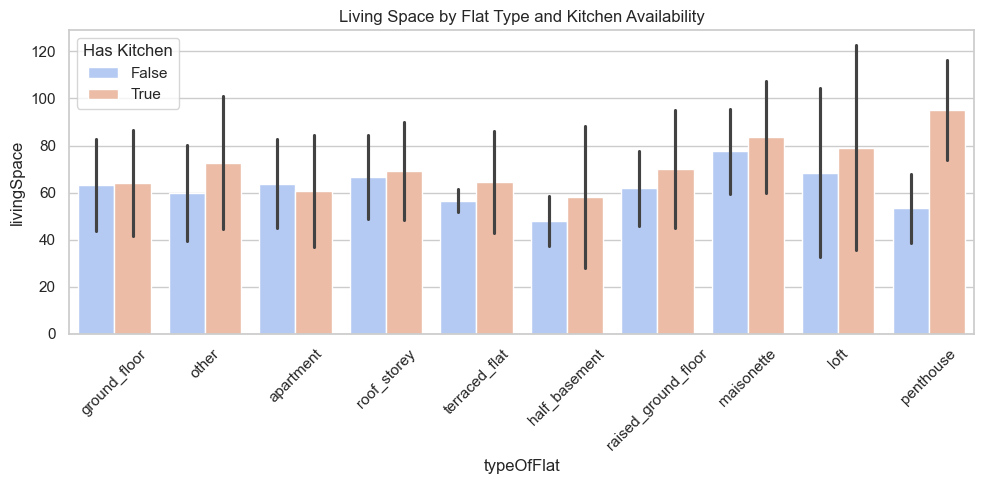

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x='typeOfFlat', y='livingSpace', hue='hasKitchen', palette='coolwarm', ci='sd')
plt.title('Living Space by Flat Type and Kitchen Availability')
plt.xticks(rotation=45)
plt.legend(title='Has Kitchen')
plt.tight_layout()
plt.show()


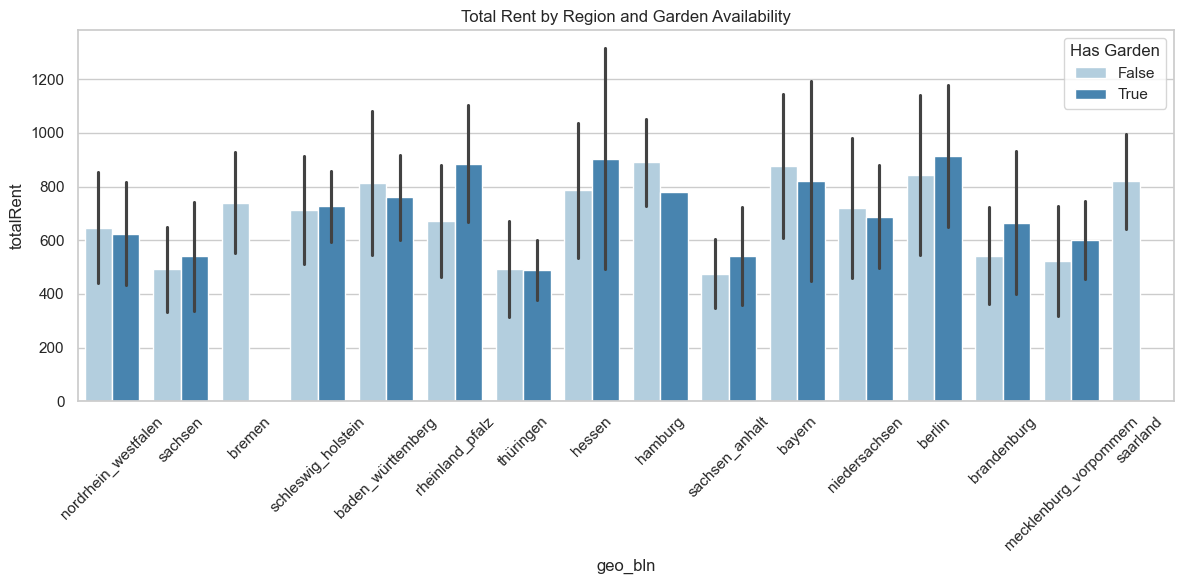

In [36]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data, x='geo_bln', y='totalRent', hue='garden', palette='Blues', ci='sd')
plt.title('Total Rent by Region and Garden Availability')
plt.xticks(rotation=45)
plt.legend(title='Has Garden')
plt.tight_layout()
plt.show()


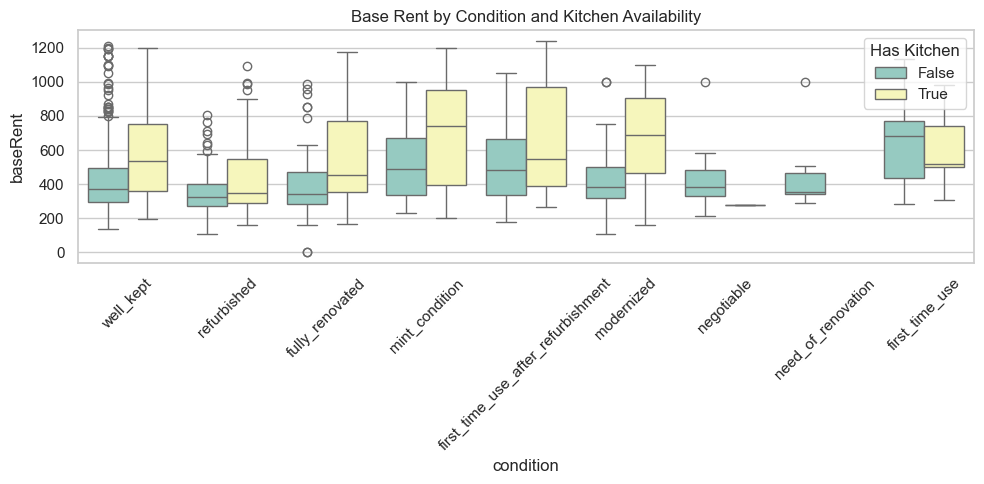

In [37]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='condition', y='baseRent', hue='hasKitchen', palette='Set3')
plt.title('Base Rent by Condition and Kitchen Availability')
plt.xticks(rotation=45)
plt.legend(title='Has Kitchen')
plt.tight_layout()
plt.show()
